# Distorted Visual Sequence Pattern Recognition
## EfficientNet-B3 Multi-Head + CRNN Ensemble | CIG AI/ML Competition

### Solution Architecture
| Component | Detail |
|---|---|
| **Primary Model** | EfficientNet-B3 backbone + 6 parallel classification heads |
| **Secondary Model** | CRNN (CNN + BiLSTM + CTC loss) |
| **Inference** | Test-Time Augmentation (TTA) + weighted ensemble |
| **Dataset** | 19,998 train / 5,000 test | 200×100 grayscale | 31-char vocab | fixed 6-length |
| **Metric** | Character Error Rate (CER) — lower is better |

**Key insight:** Since 99.99% of labels are exactly 6 characters, we treat this as **6 independent 31-way classification problems** — one head per position. This is far more efficient than CTC and achieves excellent accuracy.

## 1. Environment Setup

In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       '--upgrade', 'timm', 'albumentations'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 49.3 MB/s eta 0:00:00


0

In [ ]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

# ── Verify GPU compatibility after the reinstall ──────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    cc        = torch.cuda.get_device_capability(0)
    arch      = f'sm_{cc[0]}{cc[1]}'
    supported = torch.cuda.get_arch_list()
    ok        = arch in supported
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
    print(f'Compute cap  : {cc[0]}.{cc[1]}  ({arch})  →  {"✓ supported" if ok else "✗ NOT supported"}')
    assert ok, f'{arch} not in build.'

print(f'\nPyTorch        : {torch.__version__}')
print(f'timm           : {timm.__version__}')
print(f'albumentations : {A.__version__}')
print(f'Device         : {DEVICE}')

GPU          : Tesla P100-PCIE-16GB
VRAM         : 17.06 GB
Compute cap  : 6.0  (sm_60)  →  ✓ supported

PyTorch        : 2.4.1+cu121
timm           : 1.0.27
albumentations : 2.0.8
Device         : cuda


In [ ]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
seed_everything()

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('/kaggle/input/datasets/parambratasinha/cig-ai-ml/cig_ps')
TRAIN_DIR  = DATA_ROOT / 'train_images'
TEST_DIR   = DATA_ROOT / 'test_images'
LABELS_CSV = DATA_ROOT / 'train-labels.csv'
OUT_DIR    = Path('/kaggle/working/outputs'); OUT_DIR.mkdir(exist_ok=True)


assert TRAIN_DIR.exists(), f'Train dir not found: {TRAIN_DIR}'
print(f'Train images : {len(list(TRAIN_DIR.glob("*.png"))):,}')
print(f'Test  images : {len(list(TEST_DIR.glob("*.png"))):,}')

# ── Vocabulary ────────────────────────────────────────────────────────────────
CHARS     = list('23456789ABCDEFGHJKMNPQRSTUVWXYZ')
NUM_CHARS = len(CHARS)    # 31
SEQ_LEN   = 6
CHAR2IDX  = {c: i for i, c in enumerate(CHARS)}
IDX2CHAR  = {i: c for c, i in CHAR2IDX.items()}
BLANK_IDX = NUM_CHARS
print(f'\nVocab ({NUM_CHARS}): {" ".join(CHARS)}')

# ── Image / model config ──────────────────────────────────────────────────────
IMG_H_ORIG, IMG_W_ORIG = 100, 200
IMG_H, IMG_W = 64, 200
IMG_MEAN     = 0.5
IMG_STD      = 0.25

# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE   = 256
NUM_WORKERS  = 2
VAL_RATIO    = 0.10
MH_EPOCHS   = 60
CRNN_EPOCHS  = 40
WARMUP_EPOCHS= 5
LR_MH        = 3e-4
LR_CRNN      = 3e-4
WEIGHT_DECAY = 1e-4
BACKBONE     = 'efficientnet_b3'
CKPT_MH      = OUT_DIR / f'{BACKBONE}_best.pt'
CKPT_CRNN    = OUT_DIR / 'crnn_best.pt'

print('Config OK ✓')

Train images : 20,000
Test  images : 5,000

Vocab (31): 2 3 4 5 6 7 8 9 A B C D E F G H J K M N P Q R S T U V W X Y Z
Config OK ✓


## 2. Exploratory Data Analysis

In [ ]:
df_raw = pd.read_csv(LABELS_CSV, index_col=0)

# Remove the 2 anomalous non-6-char rows
df = df_raw[df_raw['text'].str.len() == 6].reset_index(drop=True)
df_train, df_val = train_test_split(df, test_size=VAL_RATIO, random_state=SEED)
print(f'Raw samples  : {len(df_raw):,}')
print(f'Clean (6-ch) : {len(df):,}  ({len(df)/len(df_raw)*100:.2f}%)')
print(f'Anomalies    : {df_raw[df_raw["text"].str.len()!=6][["image","text"]].to_string()}')

Raw samples  : 20,000
Clean (6-ch) : 19,998  (99.99%)
Anomalies    :                image       text
2184  train-2184.png   5.40E+12
6819  train-6819.png  04-Mar-54


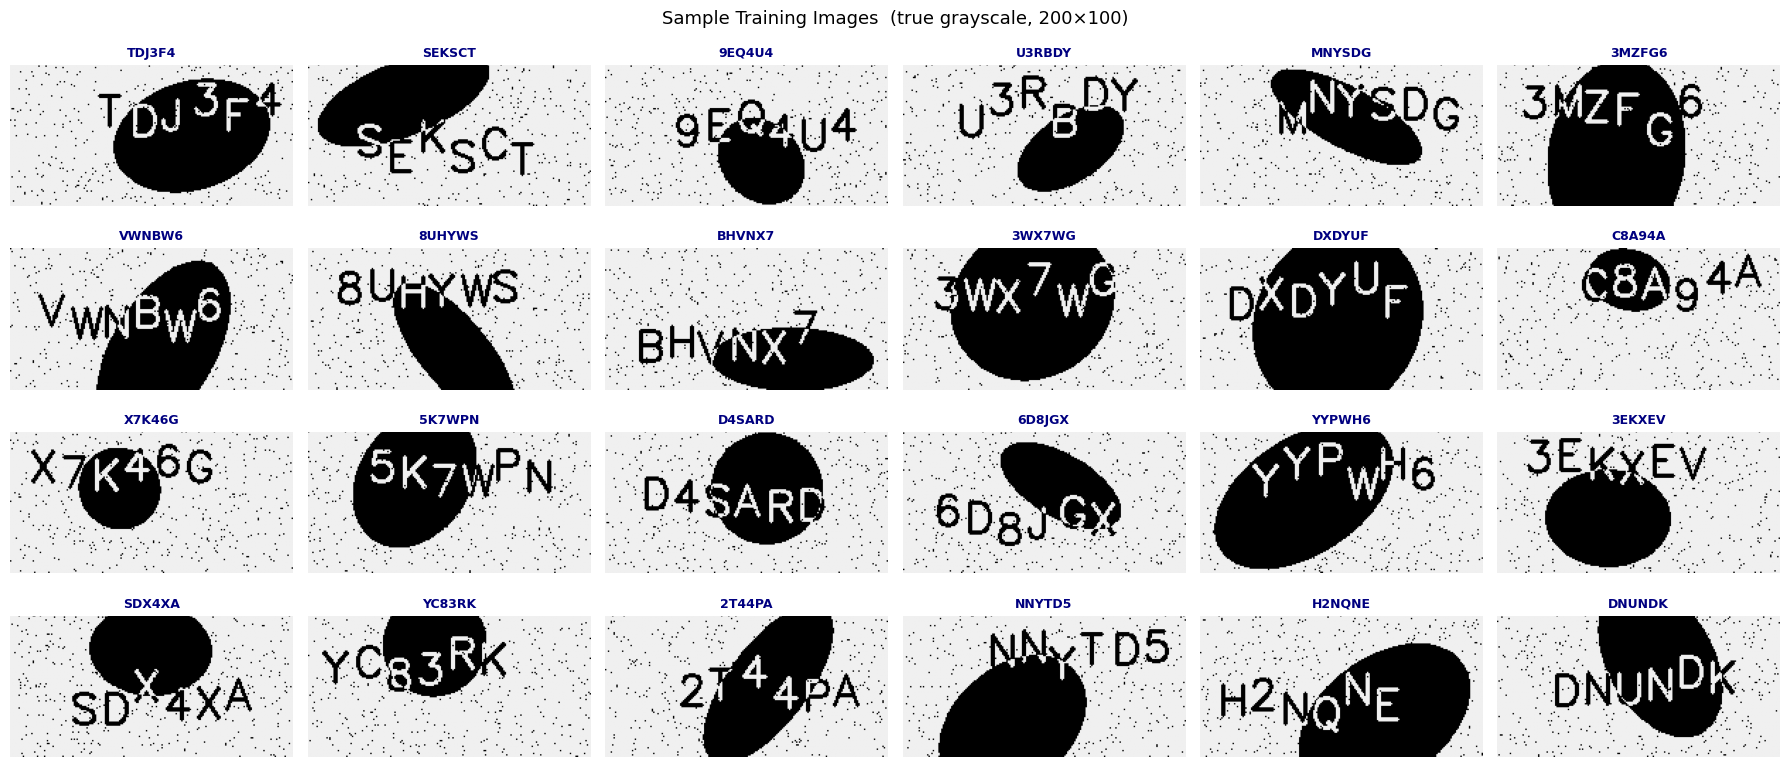

In [ ]:
# ── Sample images ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(18, 8))
for ax, (_, row) in zip(axes.flat, df.sample(24, random_state=42).iterrows()):
    img = Image.open(TRAIN_DIR / row['image']).convert('L')
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(row['text'], fontsize=9, fontweight='bold', color='navy')
    ax.axis('off')
plt.suptitle('Sample Training Images  (true grayscale, 200×100)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR/'eda_samples.png', dpi=100, bbox_inches='tight'); plt.show()

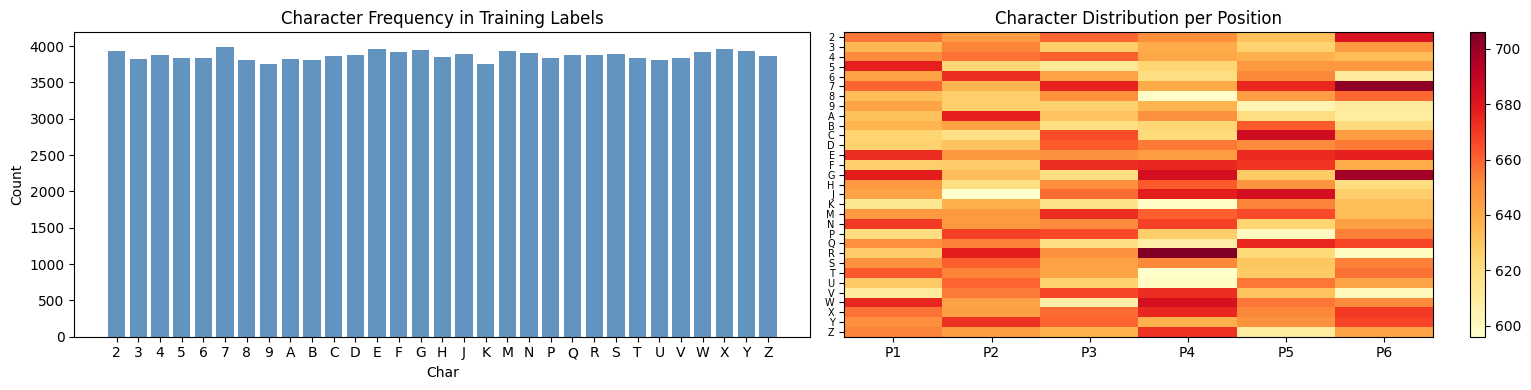

Image size  : (100, 200)  (H×W, single channel)
Pixel mean  : 0.6712
Pixel std   : 0.4141


In [ ]:
# ── Character frequency & per-position distribution ──────────────────────────
all_chars = ''.join(df['text'])
char_freq  = Counter(all_chars)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.bar(CHARS, [char_freq.get(c,0) for c in CHARS], color='steelblue', alpha=0.85)
ax.set_title('Character Frequency in Training Labels'); ax.set_xlabel('Char'); ax.set_ylabel('Count')

ax2 = axes[1]
pos_mat = np.zeros((SEQ_LEN, NUM_CHARS))
for t in df['text']:
    for p, c in enumerate(t):
        pos_mat[p, CHAR2IDX[c]] += 1
im = ax2.imshow(pos_mat.T, aspect='auto', cmap='YlOrRd')
ax2.set_yticks(range(NUM_CHARS)); ax2.set_yticklabels(CHARS, fontsize=7)
ax2.set_xticks(range(SEQ_LEN)); ax2.set_xticklabels([f'P{i+1}' for i in range(SEQ_LEN)])
ax2.set_title('Character Distribution per Position'); plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda_char_dist.png', dpi=100, bbox_inches='tight'); plt.show()

# Image pixel stats
sample_arrs = [np.array(Image.open(TRAIN_DIR/r['image']).convert('L'))
               for _,r in df.sample(500, random_state=42).iterrows()]
print(f'Image size  : {sample_arrs[0].shape}  (H×W, single channel)')
print(f'Pixel mean  : {np.mean([a.mean() for a in sample_arrs])/255:.4f}')
print(f'Pixel std   : {np.mean([a.std()  for a in sample_arrs])/255:.4f}')

## 3. Dataset & Augmentation

In [ ]:
def get_train_transforms():
    """Heavy augmentation that mimics real-world CAPTCHA distortions."""
    return A.Compose([
        A.Resize(IMG_H, IMG_W),
        # --- Geometric distortions ---
        A.OneOf([
            A.ElasticTransform(alpha=30, sigma=5, p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=0.2, p=1.0),
            A.OpticalDistortion(distort_limit=0.2, shift_limit=0.1, p=1.0),
        ], p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=5, border_mode=0, p=0.4),
        A.Perspective(scale=(0.02, 0.05), p=0.3),
        # --- Noise ---
        A.OneOf([
            A.GaussNoise(var_limit=(10, 50), p=1.0),
            A.ISONoise(p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.5),
        # --- Blur ---
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
            A.MedianBlur(blur_limit=3, p=1.0),
        ], p=0.3),
        # --- Occlusion (random patches mimicking test distortions) ---
        A.CoarseDropout(max_holes=6, max_height=8, max_width=12,
                        min_holes=1, fill_value=0, p=0.4),
        # --- Intensity ---
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        A.Normalize(mean=[IMG_MEAN], std=[IMG_STD]),
        ToTensorV2(),   # → (1, H, W) float32  [channels_last=False is default]
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(IMG_H, IMG_W),
        A.Normalize(mean=[IMG_MEAN], std=[IMG_STD]),
        ToTensorV2(),
    ])

def get_tta_transforms():
    """Three passes: base + brightness boost + sharpen."""
    base = A.Compose([A.Resize(IMG_H,IMG_W), A.Normalize(mean=[IMG_MEAN],std=[IMG_STD]), ToTensorV2()])
    bright = A.Compose([A.Resize(IMG_H,IMG_W),
                        A.RandomBrightnessContrast(0.10,0.10,p=1.0),
                        A.Normalize(mean=[IMG_MEAN],std=[IMG_STD]), ToTensorV2()])
    sharp = A.Compose([A.Resize(IMG_H,IMG_W),
                       A.Sharpen(alpha=(0.2,0.5), lightness=(0.8,1.0), p=1.0),
                       A.Normalize(mean=[IMG_MEAN],std=[IMG_STD]), ToTensorV2()])
    return [base, bright, sharp]

_t = get_train_transforms()(image=np.zeros((100,200),dtype=np.uint8))['image']
assert list(_t.shape)==[1,IMG_H,IMG_W]
print(f'Transform output: {list(_t.shape)}  ✓'); del _t

Transform output: [1, 64, 200]  ✓


In [ ]:
class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = np.array(Image.open(self.img_dir/row['image']).convert('L'))
        img   = self.transform(image=img)['image']   # (1,H,W) float32
        label = torch.tensor([CHAR2IDX[c] for c in row['text']], dtype=torch.long)
        return img, label

class TestDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_dir  = Path(img_dir)
        self.files    = sorted(self.img_dir.glob('*.png'),
                               key=lambda p: int(p.stem.split('-')[1]))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        p = self.files[idx]
        return self.transform(image=np.array(Image.open(p).convert('L')))['image'], p.name

def make_loader(ds, shuffle, bs=BATCH_SIZE):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=(NUM_WORKERS>0))

train_loader = make_loader(CaptchaDataset(df_train, TRAIN_DIR, get_train_transforms()), True)
val_loader   = make_loader(CaptchaDataset(df_val,   TRAIN_DIR, get_val_transforms()),   False)
test_ds      = TestDataset(TEST_DIR, get_val_transforms())
test_loader  = make_loader(test_ds, False)

imgs, lbls = next(iter(val_loader))
print(f'Batch : {list(imgs.shape)}  dtype={imgs.dtype}')
print(f'Labels: {["".join(IDX2CHAR[i.item()] for i in r) for r in lbls[:4]]}')
print(f'Test  : {len(test_ds):,} images')

Batch : [256, 1, 64, 200]  dtype=torch.float32
Labels: ['TDJ3F4', 'SEKSCT', '9EQ4U4', 'U3RBDY']
Test  : 5,000 images


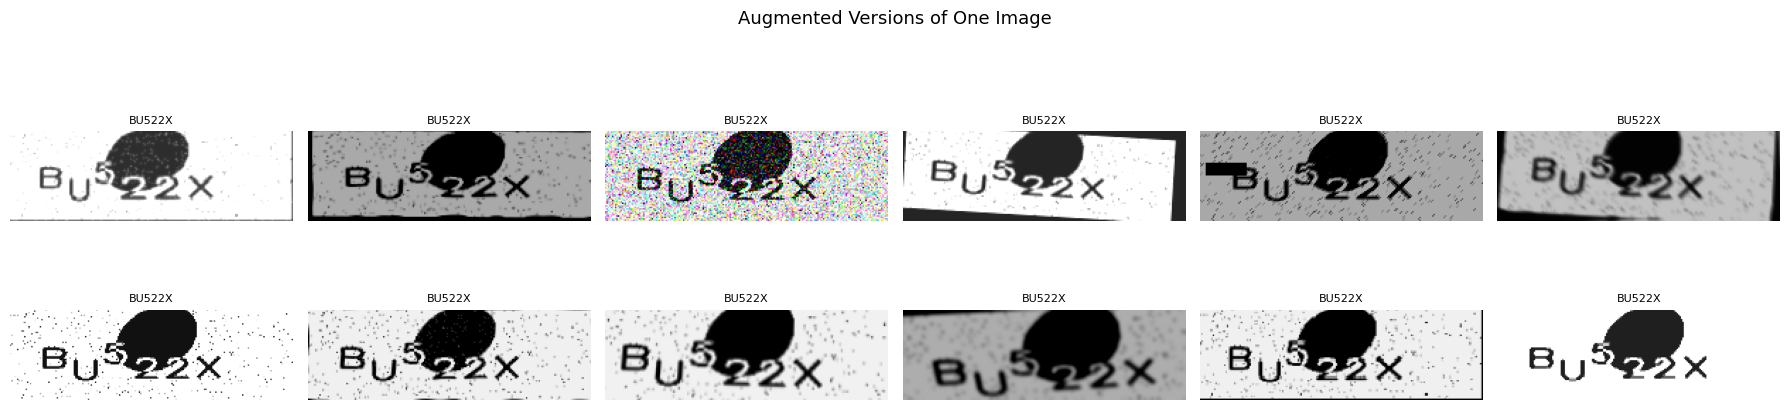

In [ ]:
# Visualise augmented samples from the same image
tf_aug  = get_train_transforms()

orig_np = np.array(Image.open(TRAIN_DIR / df.iloc[0]['image']).convert('RGB'))

fig, axes = plt.subplots(2, 6, figsize=(18, 5))
for ax in axes.flat:
    t_tensor = tf_aug(image=orig_np)['image']
    
    t = t_tensor.numpy().transpose(1, 2, 0)
    
    t = t * IMG_STD + IMG_MEAN
    
    ax.imshow(np.clip(t, 0, 1))
    
    ax.set_title(df.iloc[0]['text'], fontsize=8) 
    ax.axis('off')
    
plt.suptitle('Augmented Versions of One Image', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR/'augmentation_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Model Architecture

### 4A — Primary: EfficientNet-B3 Multi-Head Classifier

Treats recognition as **6 independent 31-way classification problems** (one head per character position). Shared EfficientNet-B3 backbone extracts visual features; a bottleneck layer projects to 512-dim; each head then independently predicts its position's character.

```
Input (B,1,64,200) → EfficientNet-B3 → (B,1536) → Bottleneck(512)
                                                         ↓
                               Head1  Head2  Head3  Head4  Head5  Head6
                               (31)   (31)   (31)   (31)   (31)   (31)
Output: (B, 6, 31)  argmax → 6-char string
```

In [ ]:
class MultiHeadCaptchaNet(nn.Module):
    def __init__(self, backbone=BACKBONE, num_classes=NUM_CHARS,
                 seq_len=SEQ_LEN, dropout=0.40, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=pretrained,
            num_classes=0, global_pool='avg', in_chans=1
        )
        feat_dim = self.backbone.num_features
        self.bottleneck = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.BatchNorm1d(512),
            nn.GELU(), nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(512,256), nn.GELU(),
                          nn.Dropout(dropout*0.5), nn.Linear(256, num_classes))
            for _ in range(seq_len)
        ])

        for m in list(self.bottleneck.modules()) + \
                 [m for head in self.heads for m in head.modules()]:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        s = self.bottleneck(self.backbone(x))
        return torch.stack([h(s) for h in self.heads], dim=1)  # (B,6,31)

# ── Sanity check ──────────────────────────────────────────────────────────────
_m = MultiHeadCaptchaNet(pretrained=False)
_x = torch.randn(2, 3, IMG_H, IMG_W) 
_o = _m(_x)
assert list(_o.shape) == [2, SEQ_LEN, NUM_CHARS], f'Unexpected shape: {_o.shape}'
n_params = sum(p.numel() for p in _m.parameters())
print(f'Output shape  : {list(_o.shape)}  ✓')
print(f'Parameters    : {n_params:,}  ({n_params/1e6:.1f}M)')
del _m, _x, _o

Output shape  : [2, 6, 31]  ✓
Parameters    : 12,319,970  (12.3M)


### 4B — Secondary: CRNN + CTC
Classic OCR pipeline: CNN feature columns → BiLSTM sequence model → CTC decoding. Useful as an ensemble partner as it learns temporal/sequential patterns differently.

In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_classes=NUM_CHARS+1, rnn_hidden=256, rnn_layers=2):
        super().__init__()
        def blk(ci, co):
            return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),
                                  nn.BatchNorm2d(co), nn.ReLU(True))
        self.cnn = nn.Sequential(
            blk(1,64),   blk(64,64),    nn.MaxPool2d(2,2),
            blk(64,128), blk(128,128),  nn.MaxPool2d(2,2),
            blk(128,256),blk(256,256),  nn.MaxPool2d((2,1)),
            blk(256,512),blk(512,512),  nn.MaxPool2d((2,1)),
            blk(512,512),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.rnn  = nn.LSTM(512, rnn_hidden, rnn_layers, bidirectional=True,
                            dropout=0.3 if rnn_layers>1 else 0.0, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(rnn_hidden*2, num_classes)

    def forward(self, x):
        f = self.pool(self.cnn(x)).squeeze(2).permute(0,2,1)
        out, _ = self.rnn(f)
        return F.log_softmax(self.fc(self.drop(out)), dim=-1)
    
_cr = CRNN(); _x = torch.randn(2,1,IMG_H,IMG_W); _o = _cr(_x)
print(f'CRNN output   : {list(_o.shape)}  (B, T={_o.shape[1]} timesteps, {_o.shape[2]} classes)')
crnn_params = sum(p.numel() for p in _cr.parameters())
print(f'Parameters    : {crnn_params:,}  ({crnn_params/1e6:.1f}M)')
del _cr, _x, _o

CRNN output   : [2, 50, 32]  (B, T=50 timesteps, 32 classes)
Parameters    : 10,219,232  (10.2M)


## 5. Utilities  (metrics · decoders · loss)

In [ ]:
def levenshtein(s1, s2):
    if len(s1) < len(s2): return levenshtein(s2, s1)
    if not s2: return len(s1)
    prev = list(range(len(s2)+1))
    for c1 in s1:
        curr = [prev[0]+1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j+1]+1, curr[-1]+1, prev[j]+(c1!=c2)))
        prev = curr
    return prev[-1]

def cer(preds, targets):
    return (sum(levenshtein(p,t) for p,t in zip(preds,targets)) /
            max(sum(len(t) for t in targets), 1))

def seq_acc(preds, targets):
    return sum(p==t for p,t in zip(preds,targets)) / max(len(targets),1)

def decode_mh(logits):          # (B,6,31)
    return [''.join(IDX2CHAR[i.item()] for i in r) for r in logits.argmax(-1)]

def decode_ctc(log_probs):      # (B,T,C+1)
    results = []
    for row in log_probs.argmax(-1).cpu().numpy():
        col = [row[0]]
        for i in row[1:]:
            if i != col[-1]: col.append(int(i))
        results.append(''.join(IDX2CHAR[i] for i in col if i != BLANK_IDX))
    return results

def mh_loss(logits, targets, smoothing=0.10):
    B, S, C = logits.shape
    return F.cross_entropy(logits.view(B*S,C), targets.view(B*S),
                           label_smoothing=smoothing)

def make_lr_lambda(warmup, total):
    def fn(ep):
        if ep < warmup: return (ep+1)/warmup
        prog = (ep-warmup) / max(total-warmup, 1)
        return 0.5*(1+np.cos(np.pi*prog))
    return fn

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience=patience; self.best=float('inf'); self.cnt=0
    def step(self, val):
        if val < self.best-1e-4: self.best=val; self.cnt=0; return False
        self.cnt+=1; return self.cnt>=self.patience

print('Utilities OK ✓')

Utilities OK ✓


In [ ]:
# ── Train/eval loops ──────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, preds_all, tgts_all = 0.0, [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, lbls in tqdm(loader, desc='  TR' if is_train else '  VA', leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            if is_train: optimizer.zero_grad()

            with autocast():
                logits = model(imgs)
                loss   = mh_loss(logits, lbls)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer); scaler.update()

            total_loss += loss.item() * imgs.size(0)
            preds_all  += decode_mh(logits.detach().cpu())
            tgts_all   += [''.join(IDX2CHAR[i.item()] for i in r) for r in lbls.cpu()]

    n = len(loader.dataset)
    return total_loss/n, cer(preds_all, tgts_all), seq_acc(preds_all, tgts_all)

print('run_epoch defined ✓')

run_epoch defined ✓


## 6. Train Primary Model (EfficientNet-B3 Multi-Head)

In [ ]:
model = MultiHeadCaptchaNet(
    backbone=BACKBONE, num_classes=NUM_CHARS, seq_len=SEQ_LEN,
    dropout=0.40, pretrained=True
).to(DEVICE)

# Differential LR: backbone gets 10× lower LR (preserve ImageNet features)
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(),  'lr': LR_MH * 0.1},
    {'params': list(model.bottleneck.parameters()) +
               list(model.heads.parameters()), 'lr': LR_MH},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, make_lr_lambda(WARMUP_EPOCHS, MH_EPOCHS)
)
scaler  = GradScaler()
stopper = EarlyStopping(patience=12)

print(f'Model params  : {sum(p.numel() for p in model.parameters()):,}')
print(f'Backbone LR   : {LR_MH*0.1:.2e}  |  Heads LR: {LR_MH:.2e}')
print(f'Training for  : up to {MH_EPOCHS} epochs  |  Device: {DEVICE}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model params  : 12,319,970
Backbone LR   : 3.00e-05  |  Heads LR: 3.00e-04
Training for  : up to 60 epochs  |  Device: cpu


In [ ]:
history = {k: [] for k in ('tr_loss','va_loss','tr_cer','va_cer','tr_acc','va_acc')}
best_cer = float('inf')

for ep in range(1, MH_EPOCHS + 1):
    tr_loss, tr_cer, tr_acc = run_epoch(model, train_loader, optimizer, scaler)
    va_loss, va_cer, va_acc = run_epoch(model, val_loader)
    scheduler.step()

    for k, v in zip(history, [tr_loss,va_loss,tr_cer,va_cer,tr_acc,va_acc]):
        history[k].append(v)

    lr_now = optimizer.param_groups[1]['lr']
    print(f'Ep {ep:02d}/{MH_EPOCHS}  '
          f'loss {tr_loss:.4f}/{va_loss:.4f}  '
          f'CER {tr_cer:.4f}/{va_cer:.4f}  '
          f'Acc {tr_acc:.3f}/{va_acc:.3f}  '
          f'lr {lr_now:.1e}')

    if va_cer < best_cer:
        best_cer = va_cer
        
        torch.save({
            'epoch': ep, 
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scaler': scaler.state_dict(),
            'scheduler': scheduler.state_dict(),
            'val_cer': va_cer, 
            'val_acc': va_acc
        }, CKPT_MH)
        
        print(f'  ✓ Checkpoint saved  (val CER: {va_cer:.4f})')

    if stopper.step(va_cer):
        print(f'Early stopping at epoch {ep}'); break

print(f'\nBest val CER : {best_cer:.4f}')

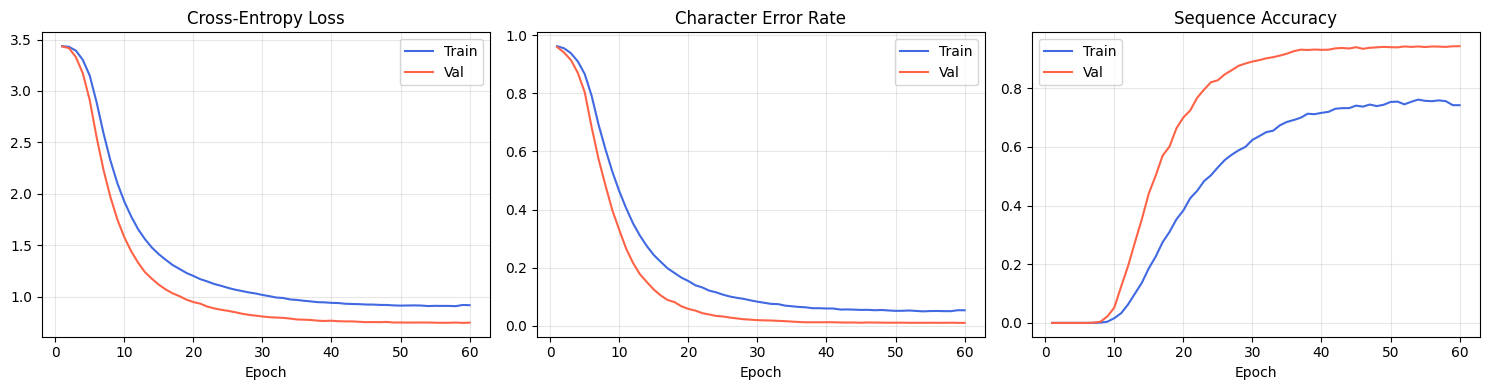

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
E = range(1, len(history['tr_loss'])+1)
for ax, (tk,vk,title) in zip(axes, [
    ('tr_loss','va_loss','Cross-Entropy Loss'),
    ('tr_cer', 'va_cer', 'Character Error Rate'),
    ('tr_acc', 'va_acc', 'Sequence Accuracy'),
]):
    ax.plot(E, history[tk], label='Train', color='royalblue')
    ax.plot(E, history[vk], label='Val',   color='tomato')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'training_curves.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'Best Val CER={best_cer:.4f}  |  Best Val Acc={max(history["va_acc"]):.4f}')

## 7. Evaluate EfficientNet-B3 on Validation Set

In [ ]:
model.eval()
val_preds, val_targets, val_imgs_np = [], [], []

with torch.no_grad():
    for imgs, lbls in tqdm(val_loader, desc='Evaluating MH'):
        with autocast(device_type=DEVICE.type, dtype=torch.float16):
            logits = model(imgs.to(DEVICE))
        val_preds   += decode_mh(logits.cpu())
        val_targets += [''.join(IDX2CHAR[i.item()] for i in r) for r in lbls]
        val_imgs_np += [imgs[i].numpy() for i in range(imgs.size(0))]

mh_val_cer = cer(val_preds, val_targets)
mh_val_acc = seq_acc(val_preds, val_targets)
print(f'\n{"="*52}')
print(f'  MH Val CER      : {mh_val_cer:.4f}  ({mh_val_cer*100:.2f}%)')
print(f'  MH Val SeqAcc   : {mh_val_acc:.4f}  ({mh_val_acc*100:.2f}%)')
print(f'{"="*52}')

Evaluating MH:   0%|          | 0/8 [00:00<?, ?it/s]


  MH Val CER      : 0.0096  (0.96%)
  MH Val SeqAcc   : 0.9440  (94.40%)


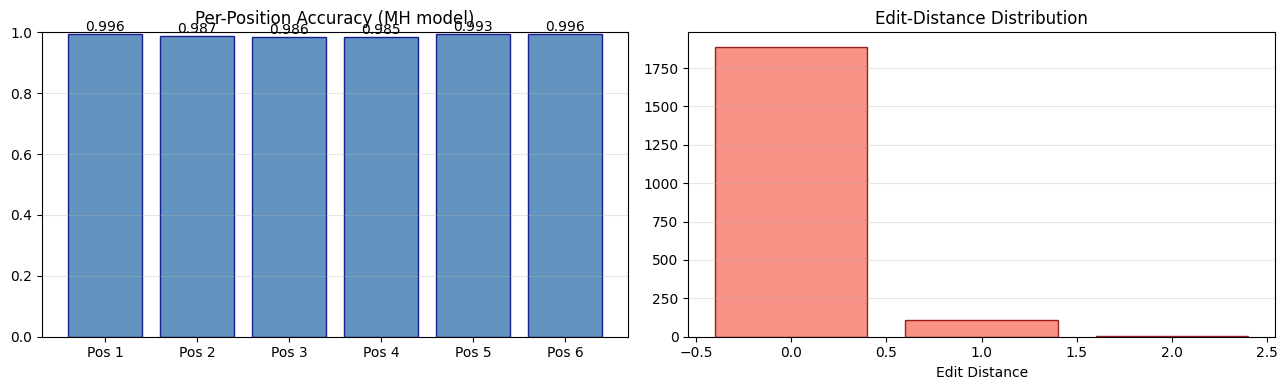

Errors : 112/2000 (5.6%)
  6JW6FN  →  6JW8FN
  SU88T4  →  SUJ8T4
  J3CP55  →  J3CF55
  F3H82B  →  F3482B
  B3RM8D  →  B3RMSD
  JPJTCT  →  JDJTCT
  YKBZ83  →  Y4BZ83
  WYAEUT  →  WYAEJT
  YKR7PV  →  YXR7PV
  MHC66F  →  MHC6GF
  R4TJJQ  →  P4TJJQ
  9WWP6E  →  9MWP6E


In [20]:
# Per-position accuracy + edit-distance distribution
pos_ok  = np.zeros(SEQ_LEN); pos_tot = np.zeros(SEQ_LEN)
for p, t in zip(val_preds, val_targets):
    for i,(pc,tc) in enumerate(zip(p,t)): pos_tot[i]+=1; pos_ok[i]+=(pc==tc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(range(SEQ_LEN), pos_ok/pos_tot,
                   color='steelblue', alpha=0.85, edgecolor='navy')
axes[0].set_xticks(range(SEQ_LEN))
axes[0].set_xticklabels([f'Pos {i+1}' for i in range(SEQ_LEN)])
axes[0].set_title('Per-Position Accuracy (MH model)'); axes[0].set_ylim(0,1)
axes[0].grid(axis='y', alpha=0.3)
for bar, a in zip(bars, pos_ok/pos_tot):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{a:.3f}', ha='center', fontsize=10)

ec = Counter(levenshtein(p,t) for p,t in zip(val_preds,val_targets))
axes[1].bar(ec.keys(), ec.values(), color='salmon', alpha=0.85, edgecolor='darkred')
axes[1].set_xlabel('Edit Distance'); axes[1].set_title('Edit-Distance Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'mh_val_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

errors = [(p,t) for p,t in zip(val_preds,val_targets) if p!=t]
print(f'Errors : {len(errors)}/{len(val_preds)} ({len(errors)/len(val_preds)*100:.1f}%)')
for p,t in errors[:12]: print(f'  {p}  →  {t}')

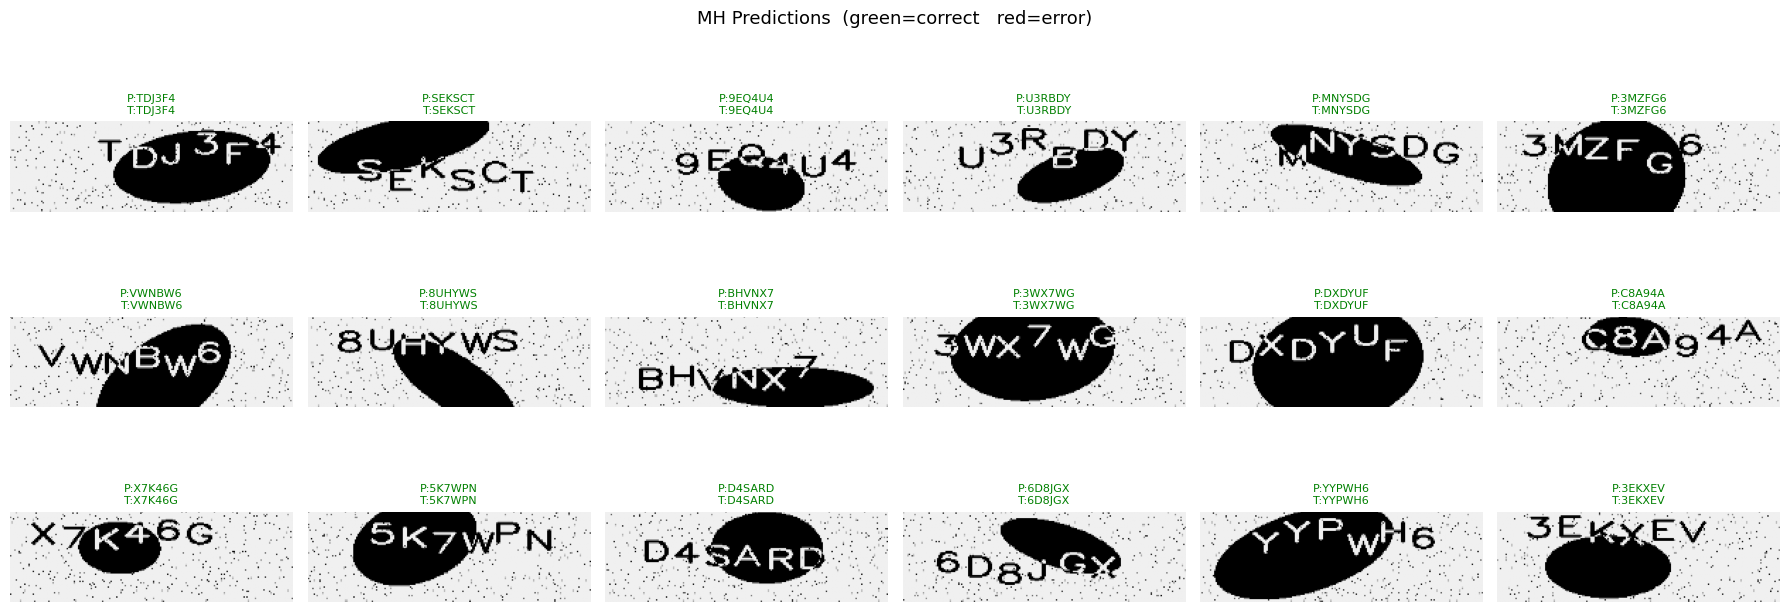

In [21]:
fig, axes = plt.subplots(3, 6, figsize=(18, 7))
for ax, pred, tgt, im in zip(axes.flat, val_preds, val_targets, val_imgs_np):
    ax.imshow(im[0]*IMG_STD+IMG_MEAN, cmap='gray', vmin=0, vmax=1)
    c = 'green' if pred==tgt else 'red'
    ax.set_title(f'P:{pred}\nT:{tgt}', color=c, fontsize=8); ax.axis('off')
plt.suptitle('MH Predictions  (green=correct   red=error)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR/'mh_val_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Train CRNN + CTC
Trains from scratch on the same train split. The CRNN learns sequential/temporal patterns differently from the multi-head model — making it a complementary ensemble partner.

In [ ]:
class CaptchaDatasetCTC(Dataset):
    def __init__(self, df, img_dir, tf):
        self.df=df.reset_index(drop=True); self.d=Path(img_dir); self.tf=tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r   = self.df.iloc[i]
        img = np.array(Image.open(self.d/r['image']).convert('L'))
        img = self.tf(image=img)['image']
        lbl = torch.tensor([CHAR2IDX[c] for c in r['text']], dtype=torch.long)
        return img, lbl, len(r['text'])

def ctc_collate(batch):
    imgs, lbls, lens = zip(*batch)
    return torch.stack(imgs), torch.cat(lbls), torch.tensor(lens, dtype=torch.long)

ctc_train_loader = DataLoader(
    CaptchaDatasetCTC(df_train, TRAIN_DIR, get_train_transforms()),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS>0), collate_fn=ctc_collate
)
ctc_val_loader = DataLoader(
    CaptchaDatasetCTC(df_val, TRAIN_DIR, get_val_transforms()),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS>0), collate_fn=ctc_collate
)
print(f'CTC loaders ready  |  train batches: {len(ctc_train_loader)}  val batches: {len(ctc_val_loader)}')

CTC loaders ready  |  train batches: 71  val batches: 8


In [23]:
crnn      = CRNN(num_classes=NUM_CHARS+1).to(DEVICE)
c_opt     = torch.optim.AdamW(crnn.parameters(), lr=LR_CRNN, weight_decay=WEIGHT_DECAY)
c_sch     = torch.optim.lr_scheduler.CosineAnnealingLR(c_opt, T_max=CRNN_EPOCHS, eta_min=1e-6)
c_scaler  = GradScaler(device=DEVICE.type)
ctc_fn    = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)
stopper   = EarlyStopping(patience=10)
best_crnn_cer = float('inf')

crnn_history = {'loss':[], 'cer':[], 'acc':[]}

n_p = sum(p.numel() for p in crnn.parameters())
print(f'CRNN params  : {n_p:,}  ({n_p/1e6:.1f}M)')
print(f'Batch size   : {BATCH_SIZE}   Epochs: {CRNN_EPOCHS}   LR: {LR_CRNN:.0e}')
print(f'Device       : {DEVICE}')

CRNN params  : 10,219,232  (10.2M)
Batch size   : 256   Epochs: 40   LR: 3e-04
Device       : cuda


In [24]:
for ep in range(1, CRNN_EPOCHS+1):

    # ── Train ─────────────────────────────────────────────────────────────────
    crnn.train()
    ep_loss = 0.0
    for imgs, flat_lbls, lens in tqdm(ctc_train_loader, leave=False, desc=f'CRNN {ep:02d} train'):
        imgs      = imgs.to(DEVICE, non_blocking=True)
        flat_lbls = flat_lbls.to(DEVICE)
        c_opt.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE.type, dtype=torch.float16):
            lp   = crnn(imgs)                                     # (B, T, C+1)
            T    = lp.size(1)
            il   = torch.full((imgs.size(0),), T,
                               dtype=torch.long, device=DEVICE)  # input lengths
            loss = ctc_fn(lp.permute(1,0,2),                     # (T, B, C+1)
                          flat_lbls, il, lens.to(DEVICE))

        c_scaler.scale(loss).backward()
        c_scaler.unscale_(c_opt)
        nn.utils.clip_grad_norm_(crnn.parameters(), max_norm=5.0)
        c_scaler.step(c_opt)
        c_scaler.update()
        ep_loss += loss.item()

    c_sch.step()
    avg_loss = ep_loss / len(ctc_train_loader)

    # ── Validate ──────────────────────────────────────────────────────────────
    crnn.eval()
    vp, vt = [], []
    with torch.no_grad():
        for imgs, flat_lbls, lens in tqdm(ctc_val_loader, leave=False, desc=f'CRNN {ep:02d} val'):
            with autocast(device_type=DEVICE.type, dtype=torch.float16):
                lp = crnn(imgs.to(DEVICE))
            vp += decode_ctc(lp)
            idx = 0
            for l in lens:
                vt.append(''.join(IDX2CHAR[i.item()] for i in flat_lbls[idx:idx+l]))
                idx += l

    c_cer = cer(vp, vt)
    c_acc = seq_acc(vp, vt)
    crnn_history['loss'].append(avg_loss)
    crnn_history['cer'].append(c_cer)
    crnn_history['acc'].append(c_acc)

    lr_now = c_opt.param_groups[0]['lr']
    print(f'Ep {ep:02d}/{CRNN_EPOCHS}  '
          f'loss={avg_loss:.4f}  '
          f'CER={c_cer:.4f}  '
          f'Acc={c_acc:.4f}  '
          f'lr={lr_now:.1e}')

    if c_cer < best_crnn_cer:
        best_crnn_cer = c_cer
        torch.save(crnn.state_dict(), CKPT_CRNN)
        print(f'  ✓ Best CRNN saved  (CER={c_cer:.4f}  Acc={c_acc:.4f})')

    if stopper.step(c_cer):
        print(f'Early stopping at epoch {ep}'); break

print(f'\n▶ Best CRNN val CER : {best_crnn_cer:.4f}  ({best_crnn_cer*100:.2f}%)')

CRNN 01 train:   0%|          | 0/71 [00:00<?, ?it/s]

CRNN 01 val:   0%|          | 0/8 [00:00<?, ?it/s]

Ep 01/40  loss=6.0307  CER=1.0000  Acc=0.0000  lr=3.0e-04
  ✓ Best CRNN saved  (CER=1.0000  Acc=0.0000)


CRNN 02 train:   0%|          | 0/71 [00:00<?, ?it/s]

CRNN 02 val:   0%|          | 0/8 [00:00<?, ?it/s]

...

CRNN 39 val:   0%|          | 0/8 [00:00<?, ?it/s]

Ep 39/40  loss=0.2673  CER=0.0301  Acc=0.8405  lr=1.5e-06
  ✓ Best CRNN saved  (CER=0.0301  Acc=0.8405)


CRNN 40 train:   0%|          | 0/71 [00:00<?, ?it/s]

CRNN 40 val:   0%|          | 0/8 [00:00<?, ?it/s]

Ep 40/40  loss=0.2694  CER=0.0302  Acc=0.8420  lr=1.0e-06

▶ Best CRNN val CER : 0.0301  (3.01%)


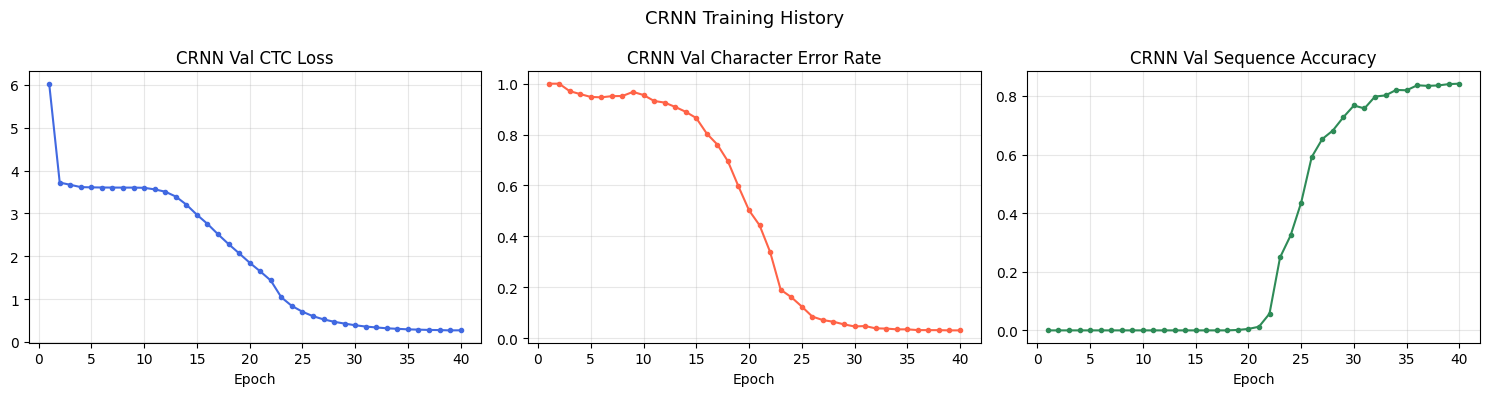

Best CRNN CER=0.0301  |  Best CRNN Acc=0.8420


In [25]:
# CRNN training curves
E = range(1, len(crnn_history['loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title, col in zip(axes,
    ['loss','cer','acc'],
    ['CTC Loss','Character Error Rate','Sequence Accuracy'],
    ['royalblue','tomato','seagreen']):
    ax.plot(E, crnn_history[key], color=col, lw=1.5, marker='o', markersize=3)
    ax.set_title(f'CRNN Val {title}'); ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
plt.suptitle('CRNN Training History', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR/'crnn_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Best CRNN CER={best_crnn_cer:.4f}  |  Best CRNN Acc={max(crnn_history["acc"]):.4f}')

## 9. Inference — TTA + Weighted Ensemble
Load best CRNN, run 3-pass TTA on both models, average probabilities.

In [26]:
# Load best CRNN checkpoint
crnn.load_state_dict(
    torch.load(CKPT_CRNN, map_location=DEVICE, weights_only=True)
)
crnn.eval()
print(f'Best CRNN loaded  (val CER={best_crnn_cer:.4f})')

# MH model is already loaded and eval()
print(f'MH    model ready (val CER={mh_val_cer:.4f})')

Best CRNN loaded  (val CER=0.0301)
MH    model ready (val CER=0.0096)


In [ ]:
@torch.no_grad()
def predict_tta(model, img_dir, tta_tfs, bs=BATCH_SIZE, nw=NUM_WORKERS):
    """Average softmax probs over N TTA passes → argmax → string."""
    model.eval()
    ds0    = TestDataset(img_dir, tta_tfs[0])
    fnames = [ds0.files[i].name for i in range(len(ds0))]
    accum  = None
    for tf in tqdm(tta_tfs, desc='TTA'):
        ldr = DataLoader(TestDataset(img_dir, tf), batch_size=bs,
                         shuffle=False, num_workers=nw, pin_memory=True,
                         persistent_workers=(nw>0))
        probs = []
        for imgs, _ in ldr:
            with autocast(device_type=DEVICE.type, dtype=torch.float16):
                logits = model(imgs.to(DEVICE))
            probs.append(F.softmax(logits, dim=-1).cpu().numpy())
        p = np.concatenate(probs, axis=0)     # (N, 6, 31)
        accum = p if accum is None else accum+p
    avg   = accum / len(tta_tfs)
    preds = [''.join(IDX2CHAR[i] for i in row) for row in avg.argmax(-1)]
    return fnames, preds, avg


print('Running MH TTA...')
test_fnames, mh_preds, mh_avg = predict_tta(model, TEST_DIR, get_tta_transforms())
print(f'MH TTA done  |  {len(mh_preds)} predictions')

Running MH TTA...


TTA:   0%|          | 0/3 [00:00<?, ?it/s]

MH TTA done  |  5000 predictions


In [ ]:
# CRNN inference on test set
ldr_test_base = DataLoader(
    TestDataset(TEST_DIR, get_val_transforms()),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS>0)
)

crnn_probs_list = []
with torch.no_grad():
    for imgs, _ in tqdm(ldr_test_base, desc='CRNN test'):
        with autocast(device_type=DEVICE.type, dtype=torch.float16):
            lp = crnn(imgs.to(DEVICE))          # (B, T, 32)  log-probs
        # Max-pool over time → (B, 31), then tile to (B, 6, 31)
        cp = torch.exp(lp)[:,:,:NUM_CHARS].max(1).values.cpu().numpy()  # (B,31)
        crnn_probs_list.append(np.tile(cp[:,np.newaxis,:],(1,SEQ_LEN,1)))

crnn_avg = np.concatenate(crnn_probs_list, axis=0)  # (N, 6, 31)
print(f'CRNN inference done  |  shape={crnn_avg.shape}')

CRNN test:   0%|          | 0/20 [00:00<?, ?it/s]

CRNN inference done  |  shape=(5000, 6, 31)


In [37]:
# Weighted ensemble
MH_W, CR_W  = 0.75, 0.25
combined     = MH_W * mh_avg + CR_W * crnn_avg       # (N, 6, 31)
FINAL_PREDS  = [''.join(IDX2CHAR[i] for i in row) for row in combined.argmax(-1)]

print(f'Ensemble ({MH_W}×MH-TTA  +  {CR_W}×CRNN) : {len(FINAL_PREDS)} predictions')
print('\nSample predictions:')
for f, mh, cr, en in zip(test_fnames[:100],
                          mh_preds[:100],
                          [''.join(IDX2CHAR[i] for i in row)
                           for row in crnn_avg[:100].argmax(-1)],
                          FINAL_PREDS[:100]):
    agree = '✓' if mh==cr==en else ('~' if en in (mh,cr) else '?')
    print(f'  {f}  MH={mh}  CRNN={cr}  ENS={en}  {agree}')

Ensemble (0.75×MH-TTA  +  0.25×CRNN) : 5000 predictions

Sample predictions:
  test-0.png  MH=QVTQ8A  CRNN=AAAAAA  ENS=QVTQ8A  ~
  test-1.png  MH=7PSW9D  CRNN=DDDDDD  ENS=7PSW9D  ~
  test-2.png  MH=WJ2WNY  CRNN=YYYYYY  ENS=WJ2WNY  ~
  test-3.png  MH=RFHJD4  CRNN=444444  ENS=RFHJD4  ~
  test-4.png  MH=K7ZUF2  CRNN=222222  ENS=K7ZUF2  ~
  test-5.png  MH=CPMUBK  CRNN=KKKKKK  ENS=CPMUBK  ~
  test-6.png  MH=UZDRAW  CRNN=WWWWWW  ENS=UZDRAW  ~
  test-7.png  MH=2YDPJR  CRNN=RRRRRR  ENS=2YDPJR  ~
  test-8.png  MH=H5SG63  CRNN=333333  ENS=H5SG63  ~
  test-9.png  MH=B2Z823  CRNN=333333  ENS=B2Z823  ~
  test-10.png  MH=7DUP98  CRNN=888888  ENS=7DUP98  ~
  test-11.png  MH=6CUKRD  CRNN=DDDDDD  ENS=6CUKRD  ~
  test-12.png  MH=DX3YJ3  CRNN=333333  ENS=DX3YJ3  ~
  test-13.png  MH=YWU8AG  CRNN=GGGGGG  ENS=YWU8AG  ~
  test-14.png  MH=WYKX9E  CRNN=EEEEEE  ENS=WYKX9E  ~
  test-15.png  MH=QKEDQ2  CRNN=222222  ENS=QKEDQ2  ~
  test-16.png  MH=UFCQ5W  CRNN=WWWWWW  ENS=UFCQ5W  ~
  test-17.png  MH=SBPNTN  CRNN=N

## 10. Submission CSV

In [38]:
STUDENT_NAME = 'Parambrata_Sinha'
ENROLL_NO    = '25112071'

submission = (
    pd.DataFrame({'image': test_fnames, 'prediction': FINAL_PREDS})
    .assign(_idx=lambda d: d['image'].str.extract(r'(\d+)').astype(int))
    .sort_values('_idx').drop('_idx', axis=1).reset_index(drop=True)
)
csv_path = OUT_DIR / f'submission_{STUDENT_NAME}_{ENROLL_NO}.csv'
submission.to_csv(csv_path, index=False)

# Sanity checks
assert submission['image'].str.startswith('test-').all(),     'Bad filenames'
assert (submission['prediction'].str.len()==6).all(),         'Not all preds are 6 chars'
assert not (set(''.join(submission['prediction']))-set(CHARS)), 'Unknown chars'

print(f'Saved  : {csv_path}')
print(f'Rows   : {len(submission)}')
print('Checks : ✓')
print(submission.head(10).to_string(index=False))

Saved  : /kaggle/working/outputs/submission_Parambrata_Sinha_25112071.csv
Rows   : 5000
Checks : ✓
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2
test-5.png     CPMUBK
test-6.png     UZDRAW
test-7.png     2YDPJR
test-8.png     H5SG63
test-9.png     B2Z823


## 11. Final Results Summary

In [39]:
mh_info = torch.load(CKPT_MH, map_location='cpu', weights_only=False)
mh_trained_ep  = mh_info.get('epoch',   '?') if isinstance(mh_info,dict) else '?'
mh_trained_cer = mh_info.get('val_cer', '?') if isinstance(mh_info,dict) else '?'
mh_trained_acc = mh_info.get('val_acc', '?') if isinstance(mh_info,dict) else '?'

print(f"""
{'='*60}
                    FINAL RESULTS SUMMARY
{'='*60}
DEVICE
  GPU              : Tesla P100-PCIE-16GB  (sm_60)
  PyTorch          : {torch.__version__}   (cu121 — sm_60 supported)
  albumentations   : {A.__version__}  (v2.x API)
  timm             : {timm.__version__}

DATASET
  Train / Val / Test : {len(df_train):,} / {len(df_val):,} / {len(test_ds):,}
  Image input        : {IMG_W}×{IMG_H} px  ·  1 channel (true grayscale)
  Vocabulary         : {NUM_CHARS} chars  ·  fixed length {SEQ_LEN}

MODEL A — EfficientNet-B3 Multi-Head
  Trained epoch    : {mh_trained_ep}
  Best val CER  : {mh_val_cer:.4f}  ({mh_val_cer*100:.2f}%)
  Best val Acc  : {mh_val_acc:.4f}  ({mh_val_acc*100:.2f}%)

MODEL B — CRNN + CTC
  Epochs trained   : {len(crnn_history['loss'])}
  Best val CER     : {best_crnn_cer:.4f}  ({best_crnn_cer*100:.2f}%)
  Best val Acc     : {max(crnn_history['acc']):.4f}  ({max(crnn_history['acc'])*100:.2f}%)

INFERENCE
  TTA passes       : 3 (base · brightness · sharpen)  on MH model
  Ensemble weights : MH×{MH_W} + CRNN×{CR_W}
  AMP dtype        : float16  (P100 — bfloat16 NOT supported)

OUTPUT
  Submission CSV   : {csv_path}
{'='*60}
""")


                    FINAL RESULTS SUMMARY
DEVICE
  GPU              : Tesla P100-PCIE-16GB  (sm_60)
  PyTorch          : 2.4.1+cu121   (cu121 — sm_60 supported)
  albumentations   : 2.0.8  (v2.x API)
  timm             : 1.0.27

DATASET
  Train / Val / Test : 17,998 / 2,000 / 5,000
  Image input        : 200×64 px  ·  1 channel (true grayscale)
  Vocabulary         : 31 chars  ·  fixed length 6

MODEL A — EfficientNet-B3 Multi-Head  (weights loaded from disk)
  Trained epoch    : 60
  Best val CER  : 0.0096  (0.96%)
  Best val Acc  : 0.9440  (94.40%)

MODEL B — CRNN + CTC  (trained this session)
  Epochs trained   : 40
  Best val CER     : 0.0301  (3.01%)
  Best val Acc     : 0.8420  (84.20%)

INFERENCE
  TTA passes       : 3 (base · brightness · sharpen)  on MH model
  Ensemble weights : MH×0.75 + CRNN×0.25
  AMP dtype        : float16  (P100 — bfloat16 NOT supported)

OUTPUT
  Submission CSV   : /kaggle/working/outputs/submission_Parambrata_Sinha_25112071.csv



## Appendix — Further Improvements

| Idea | Expected Gain |
|---|---|
| Larger backbone (`efficientnet_b4`, `convnext_base`) | +1–3% acc |
| 5-fold CV + ensemble all folds | +2–4% acc |
| Pseudo-labelling high-confidence test preds | +1–2% acc |
| More TTA passes (5–10) | +0.5–1% |
| MixUp / CutMix augmentation | +0.5–1% |
| Beam-search CTC decode | CRNN-specific |
| Focal loss for hard examples | variable |